In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker
import sys
sys.path.append('../.')
from simple_reader import load_all_benchmarks, plot_normalized_scaling
from simple_reader import chunk_translation, chunk_translation_reverse
from aqua.core.graphics import ConfigStyle
from aqua.core.logger import log_configure

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Plot pure benchmark results

Data are loaded

In [4]:
results = load_all_benchmarks('array_4months/results_*128GB*.txt')
results

Found 23 benchmark files matching pattern 'array_4months/results_*128GB*.txt'.


,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
0,1,73.15,4.35,68.68,0.12,2t,64,128,6h
1,2,73.82,3.95,69.78,0.09,2t,64,128,6h
2,3,73.40,3.97,69.36,0.07,2t,64,128,6h
3,1,2110.34,4.58,2105.69,0.08,2t,1,128,3h
4,2,2127.78,4.68,2123.04,0.06,2t,1,128,3h
...,...,...,...,...,...,...,...,...,...
64,2,448.29,2.54,445.73,0.01,2t,1,128,D
65,3,452.36,2.50,449.84,0.02,2t,1,128,D
66,1,42.71,3.66,39.01,0.04,2t,32,128,D
67,2,46.37,4.40,41.95,0.03,2t,32,128,D


In [5]:
results = results[results['Workers'] != 64]

We translate the chunk sizes from string to number for plotting purposes

In [6]:
results_chunk = chunk_translation(results)
results_chunk

/Users/mnurisso/src/high_res_data_access/aqua-scripts/simple_reader/.././simple_reader/utils.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_chunk['Chunk Size'] = df_chunk['Chunk Size'].map(chunk_translation_dict)


,Attempt,Total Time (s),Retrieve Time (s),Compute Time (s),I/O Time (s),Variable,Workers,Memory (GB),Chunk Size
3,1,2110.34,4.58,2105.69,0.08,2t,1,128,3
4,2,2127.78,4.68,2123.04,0.06,2t,1,128,3
5,3,2140.20,5.04,2135.13,0.03,2t,1,128,3
6,1,166.26,3.19,162.86,0.21,2t,16,128,3
7,2,167.32,2.98,164.26,0.08,2t,16,128,3
...,...,...,...,...,...,...,...,...,...
64,2,448.29,2.54,445.73,0.01,2t,1,128,24
65,3,452.36,2.50,449.84,0.02,2t,1,128,24
66,1,42.71,3.66,39.01,0.04,2t,32,128,24
67,2,46.37,4.40,41.95,0.03,2t,32,128,24


We average over multiple runs to get mean execution times

In [7]:
baseline = results_chunk.groupby(['Workers', 'Chunk Size', 'Variable'])['Total Time (s)'].mean().reset_index(name='Mean Time')
baseline

,Workers,Chunk Size,Variable,Mean Time
0,1,3,2t,2126.106667
1,1,6,2t,1123.473333
2,1,24,2t,456.616667
3,1,168,2t,281.903333
4,2,3,2t,1091.956667
5,2,6,2t,609.433333
6,2,24,2t,269.283333
7,2,168,2t,174.563333
8,4,3,2t,547.083333
9,4,6,2t,311.386667


In [14]:
def plot_normalized_scaling_and_chunking(df, which_time='Total Time (s)', log_scale=False, title=None, loglevel='INFO'):
    """
    Plots normalized scaling and chunking performance from the given dataframe.

    Args:
        df (pd.DataFrame): DataFrame containing benchmark results with columns
                           'Workers', 'Chunk Size', 'Variable', and timing metrics.
        which_time (str): The column name in df to use for timing data.
        log_scale (bool): Whether to use logarithmic scale for the y-axis.
        title (str): Optional title for the entire figure.
        loglevel (str): Logging level for debug information.

    Returns:
        None: Displays the plots.
    """
    ConfigStyle()
    logger = log_configure(log_level=loglevel, log_name='plot_normalized_scaling_and_chunking')
    logger.info("Starting plot_normalized_scaling_and_chunking")

    # Dataset management
    df_avg =(
        df.groupby(['Workers', 'Chunk Size', 'Variable'])[which_time]
        .mean()
        .reset_index(name='Mean Time')
    )
    logger.debug(f"Averaged quantities: {df_avg}")
    normalized_scaling = []

    for chunk, group in df_avg.groupby('Chunk Size'):
        baseline_time = group.sort_values('Workers').iloc[0]['Mean Time']
        group = group.copy()
        group['Normalized Speedup'] = baseline_time / group['Mean Time']
        logger.debug(f"Chunk Size: {chunk} H, Baseline Time: {baseline_time} s")
        normalized_scaling.append(group)

    df_normalized_scaling = pd.concat(normalized_scaling)
   
    logger.debug(f"Normalized Scaling DataFrame: {df_normalized_scaling}")

    # Plot the two dataframes in two subplots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)\

    # Graphical adjustments
    titles_fontsize = 22
    labels_fontsize = 18
    tickers_fontsize = 16
    legend_fontsize = 14

    # AX0: Importance of the chunk size

    #create a log-scaled palette based on Workers
    # we don't use the full range of the colormap to avoid extremes
    workers = sorted(df_avg['Workers'].unique())
    log_vals = np.log10(workers)
    log_norm = (log_vals - log_vals.min()) / (log_vals.max() - log_vals.min() + 1e-12)
    cmap = plt.cm.plasma_r
    cmap_min, cmap_max = 0.12, 0.88
    scaled = cmap_min + log_norm * (cmap_max - cmap_min)
    palette = {int(w): cmap(v) for w, v in zip(workers, scaled)}

    sns.lineplot(data=df_avg,
                 x='Chunk Size', y='Mean Time',
                 hue='Workers',  marker='o',
                 palette=palette,
                 linewidth=2,
                 legend='auto',
                 ax=axes[0])

    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[0].set_title('Mean Execution Time by Chunk Size (128 GB)', fontsize=titles_fontsize)

    # x-ticks as human-readable values
    chunk_sizes = sorted(df_avg['Chunk Size'].unique())
    chunk_translation_dict_reverse = {
        1: 'h',
        3: '3h',
        6: '6h',
        24: 'D',
        168: 'W'
    }
    x_ticklabels = [f'{chunk_translation_dict_reverse[cs]}' for cs in chunk_sizes]
    axes[0].set_xticks(chunk_sizes)
    axes[0].set_xticklabels(x_ticklabels)
    axes[0].set_xlabel('Chunk Size', fontsize=labels_fontsize)
    axes[0].set_ylabel('Mean Execution Time [s]', fontsize=labels_fontsize)
    axes[0].tick_params(axis='both', which='major', labelsize=tickers_fontsize)

    axes[0].grid(True, which='both', linestyle='--', linewidth=0.5, axis='y')
    axes[0].legend(title='Workers', fontsize=legend_fontsize, title_fontsize=legend_fontsize)

    # AX1: Importance of the number of workers

    # create a log-scaled palette based on Chunk Size but avoid using the cmap extremes
    chunks = sorted(df_normalized_scaling['Chunk Size'].unique())
    log_vals = np.log10(np.array(chunks, dtype=float))
    log_norm = (log_vals - log_vals.min()) / (log_vals.max() - log_vals.min() + 1e-12)

    # restrict mapping to a subrange of the colormap (e.g. 12%..88%) so extremes aren't at cmap ends
    cmap = plt.cm.plasma_r
    cmap_min, cmap_max = 0.12, 0.78
    scaled = cmap_min + log_norm * (cmap_max - cmap_min)

    palette = {int(ch): cmap(v) for ch, v in zip(chunks, scaled)}

    workers_sorted = sorted(df_normalized_scaling['Workers'].unique())
    axes[1].plot(workers_sorted, np.array(workers_sorted)/workers_sorted[0],
                 linestyle='--', color='gray', label='Perfect Scaling')

    axes[1].grid(True, which='major', linestyle='--', linewidth=0.5, axis='y')

    sns.lineplot(data=df_normalized_scaling,
                 x='Workers', y='Normalized Speedup',
                 hue='Chunk Size', marker='o',
                 palette=palette,
                 linewidth=2,
                 legend='auto',
                 ax=axes[1])
    axes[1].set_xscale('log')
    axes[1].set_yscale('log')
    axes[1].set_title('Normalized Scaling by Workers (128 GB)', fontsize=titles_fontsize)
    axes[1].set_xlabel('Workers', fontsize=labels_fontsize)

    x_ticklabels = [f'{w}' for w in workers_sorted]
    axes[1].set_xticks(workers_sorted)
    axes[1].set_xticklabels(x_ticklabels)
    axes[1].tick_params(axis='both', which='major', labelsize=tickers_fontsize)
    axes[1].set_ylabel('Normalized Speedup', fontsize=labels_fontsize)

    # Update legend labels to use human-readable chunk names
    handles, labels = axes[1].get_legend_handles_labels()
    new_labels = [
        chunk_translation_dict_reverse.get(int(l), l)
        if l.isdigit() else l
        for l in labels
    ]
    logger.debug(f"Updated legend labels: {new_labels}")
    #axes[1].legend(title='Chunk Size', fontsize=legend_fontsize, title_fontsize=legend_fontsize)
    axes[1].legend(handles, new_labels, title='Chunk Size', fontsize=legend_fontsize, title_fontsize=legend_fontsize)

    if title:
        fig.suptitle(title, fontsize=titles_fontsize + 2, fontweight='bold')
    plt.tight_layout()

    fig.savefig('aqua_scaling_chunking_4months_128GB.png', dpi=600)
   

2025-12-22 12:03:59 :: plot_normalized_scaling_and_chunking :: INFO     -> Starting plot_normalized_scaling_and_chunking
2025-12-22 12:03:59 :: plot_normalized_scaling_and_chunking :: DEBUG    -> Averaged quantities:     Workers  Chunk Size Variable    Mean Time
0         1           3       2t  2126.106667
1         1           6       2t  1123.473333
2         1          24       2t   456.616667
3         1         168       2t   281.903333
4         2           3       2t  1091.956667
5         2           6       2t   609.433333
6         2          24       2t   269.283333
7         2         168       2t   174.563333
8         4           3       2t   547.083333
9         4           6       2t   311.386667
10        4          24       2t   141.320000
11        4         168       2t    98.860000
12        8           3       2t   306.683333
13        8           6       2t   181.353333
14        8          24       2t    79.263333
15       16           3       2t   166.966667
1

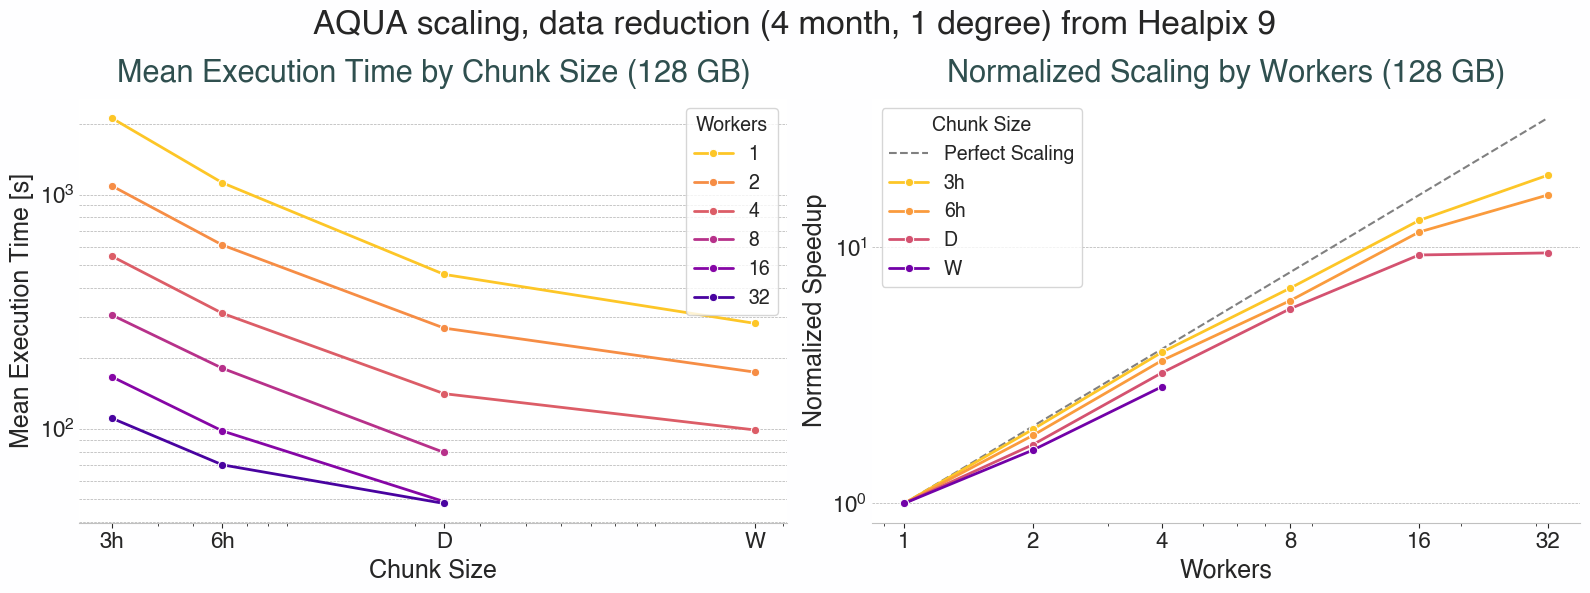

In [15]:
plot_normalized_scaling_and_chunking(results_chunk, log_scale=True, loglevel='DEBUG',
                                     title='AQUA scaling, data reduction (4 month, 1 degree) from Healpix 9')